# 918 session 10 — one video frame

Run on `hhw9l84` with `~/.virtualenvs/rfmapping`.

Show the complete original AVI frame and print the matching CSV position, CSV Rotation Z, and VS values. CSV values are printed as stored.

`draw_arc(start_deg, end_deg, xy, R)`, `draw_circle(x, y, R)`, and `draw_arrow(deg, xy)` use image pixels. `(0, 0)` is top left; 0° points up, −90° left, +90° right. Uncomment the example calls to draw on the frame.

`bearing(deg, xy, hd_deg, center, R)` uses your pixel geometry and offsets. Zero is ahead, positive is right, negative is left. The orange arc stays on the screen circle; printed bearings are relative to the head position and direction.



In [1]:
import json
import io
import subprocess
from PIL import Image
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import numpy as np
import pandas as pd
from scipy.io import loadmat

from Utils.tuning_curve_utils import get_exposure_timestamps

date = "260918"
session_dir = Path(f"/mnt/senzailab/Kai/#Recording/m20/{date}/{date}_10")
data_dir = session_dir / "data"

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "savefig.transparent": False,
    "text.color": "black", "axes.labelcolor": "black",
    "xtick.color": "black", "ytick.color": "black",
})


In [2]:
# Same CSV and VS sources as bearing_test.
motive = pd.read_csv(
    session_dir / f"{date}.csv", header=[2, 3, 6, 7], skip_blank_lines=False,
)
frame_ids = motive.iloc[:, 0].to_numpy(int)
body = motive["Rigid Body"]["hp4"]
raw_xy = body["Position"][["X", "Y"]].to_numpy()
raw_hd = body["Rotation"]["Z"].to_numpy()

trials = pd.DataFrame(loadmat(session_dir / f"{date}.mat", simplify_cells=True)["trials"])
trial_edges = np.load(data_dir / "on_list_times.npy")
vs_duration = np.stack(trials["Timing"])[:, 1]

info = json.loads((data_dir / "session_info.json").read_text())["session_info"]
exposure_time, adc_origin, _ = get_exposure_timestamps(
    info, data_dir, camera_ttl_threshold=11000, camera_ttl_active_high=True,
)
# Motive high pulses match all CSV frames; trial_edges uses the raw ADC clock.
assert len(exposure_time) == len(motive)
frame_time = exposure_time[frame_ids] + adc_origin
frame_trial = np.searchsorted(trial_edges, frame_time, side="right") - 1

valid_rows = np.flatnonzero(
    (frame_trial >= 0) & (frame_trial < len(trials))
    & np.isfinite(raw_xy).all(axis=1) & np.isfinite(raw_hd)
)
# Pick while VS is on, excluding the short gap between trials.
valid_rows = valid_rows[
    frame_time[valid_rows] - trial_edges[frame_trial[valid_rows]]
    < vs_duration[frame_trial[valid_rows]]
]
print(f"{len(motive):,} CSV frames; {len(valid_rows):,} valid frames during VS.")


193,879 CSV frames; 136,725 valid frames during VS.


In [3]:
def draw_arc(start_deg, end_deg, xy, R, ax=None, **kwargs):
    """Clockwise arc: 0=N, -90=W, 90=E; xy and R are pixels; image Y increases downward."""
    ax = plt.gca() if ax is None else ax
    if end_deg < start_deg:
        end_deg += 360  # e.g. 170 -> -170 crosses south.
    theta = np.deg2rad(np.linspace(start_deg, end_deg, 181))
    return ax.plot(xy[0] + R * np.sin(theta),
                   xy[1] - R * np.cos(theta), **kwargs)[0]


def draw_circle(x, y, R, ax=None, **kwargs):
    """Unfilled circle centered at (x, y)."""
    ax = plt.gca() if ax is None else ax
    return ax.add_patch(Circle((x, y), R, fill=False, **kwargs))


def draw_arrow(deg, xy, length=100, ax=None, **kwargs):
    """Arrow from xy toward deg: 0=N, -90=W, 90=E."""
    ax = plt.gca() if ax is None else ax
    theta = np.deg2rad(deg)
    end = np.asarray(xy) + length * np.array([np.sin(theta), -np.cos(theta)])
    return ax.add_patch(FancyArrowPatch(
        xy, end, arrowstyle="-|>", mutation_scale=15, shrinkA=0, shrinkB=0,
        **kwargs,
    ))


def bearing(deg, xy, hd_deg, center, R):
    """Use the same angles as draw_arrow; bearing is +right, -left."""
    theta = np.deg2rad(deg)
    dx = center[0] + R * np.sin(theta) - xy[0]
    dy = center[1] - R * np.cos(theta) - xy[1]
    direction = np.rad2deg(np.arctan2(dx, -dy))
    return (direction - hd_deg + 180) % 360 - 180


Motive frame 125822 | video frame 62882 | trial 10280 (0-based) | ADC time 1073.783085 s
CSV position XY: [-135.153656  -56.525627] Motive units
CSV head direction (Rotation Z): 130.74°
VS: X=30°, Y=0°, width=12°, luminance=1
VS bearing: 160.46°; edges: 156.02°, 164.99°


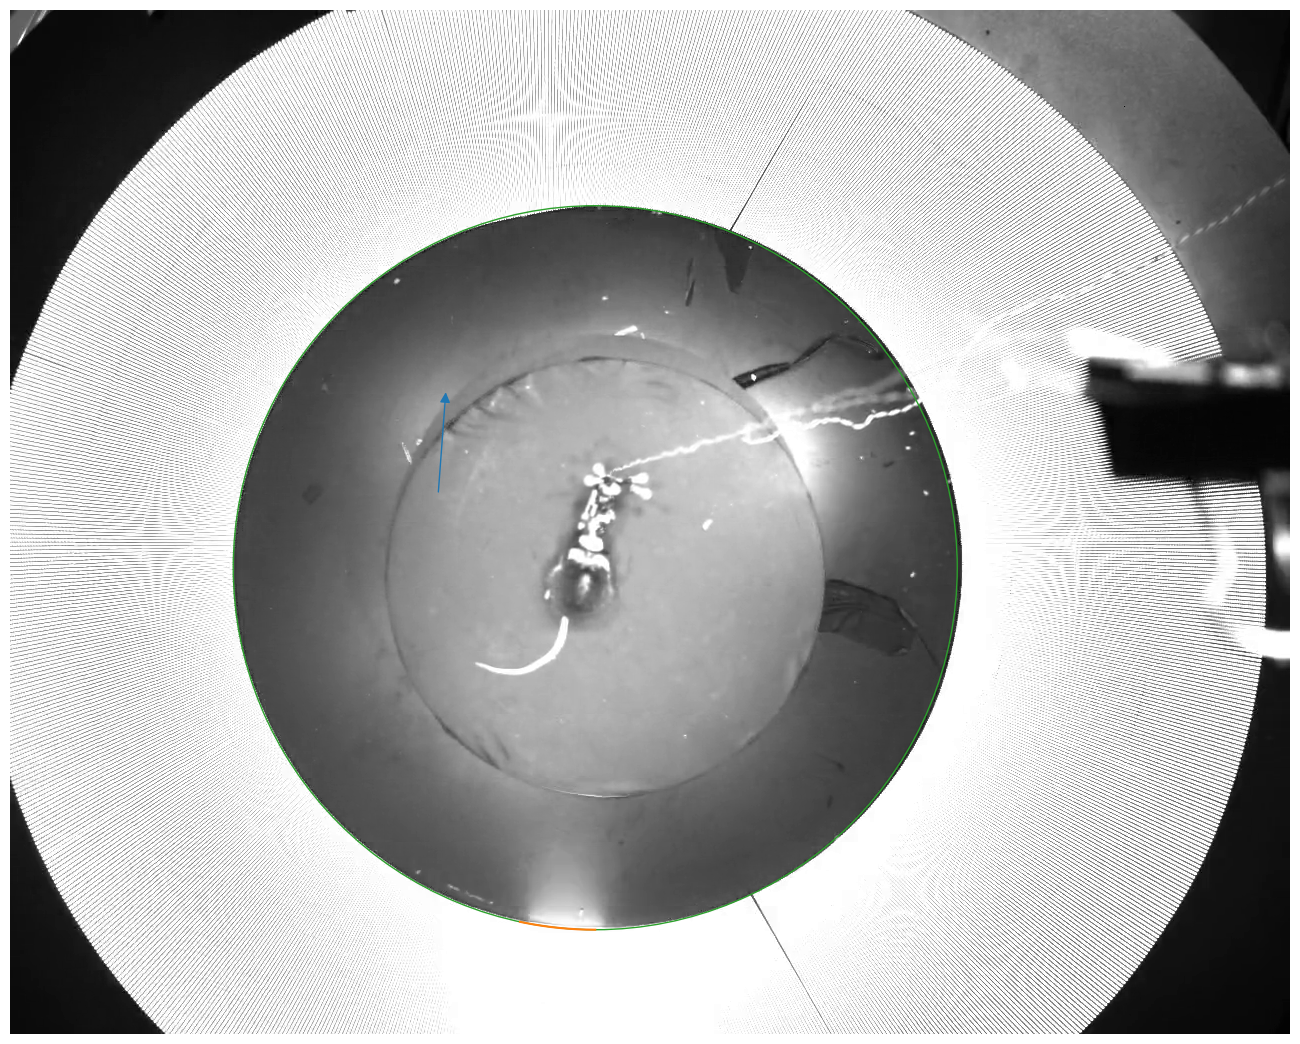

In [7]:
# Rerun this cell to pick another frame.
row = int(np.random.default_rng().choice(valid_rows[frame_ids[valid_rows] % 2 == 0]))
# row = 19060


frame = int(frame_ids[row])
# One AVI frame per two Motive frames; the 58-frame offset was checked against visible VS transitions.
video_frame = (frame - 58) // 2
video_png = subprocess.check_output([
    "ffmpeg", "-v", "error", "-threads", "4", "-i", str(session_dir / f"{date}.avi"),
    "-vf", f"select=eq(n\\,{video_frame})", "-frames:v", "1",
    "-f", "image2pipe", "-vcodec", "png", "-",
])
video_image = Image.open(io.BytesIO(video_png))
trial = int(frame_trial[row])
xy = raw_xy[row]
hd_deg = raw_hd[row]
vs_on = 0 <= trial < len(trials) and frame_time[row] - trial_edges[trial] < vs_duration[trial]
vs_deg = vs_y = vs_width = np.nan
if vs_on:
    vs = trials.iloc[trial]
    vs_deg = float(vs["Square_PositionX"])
    vs_y = float(vs["Square_PositionY"])
    vs_width = float(vs["Square_Size"])

print(f"Motive frame {frame} | video frame {video_frame} | trial {trial} (0-based) | ADC time {frame_time[row]:.6f} s")
print(f"CSV position XY: {raw_xy[row]} Motive units")
print(f"CSV head direction (Rotation Z): {hd_deg:.2f}°")
if vs_on:
    print(f"VS: X={vs_deg:g}°, Y={vs_y:g}°, width={vs_width:g}°, luminance={vs['Square_Luminance']:g}")
else:
    print("VS: off at this frame")

width, height = video_image.size
fig = plt.figure(figsize=(width / 100, height / 100), dpi=100, facecolor="white")
ax = fig.add_axes([0, 0, 1, 1])
ax.imshow(video_image)
ax.set_xlim(-0.5, width - 0.5)
ax.set_ylim(height - 0.5, -0.5)
ax.set_autoscale_on(False)
ax.set_axis_off()

# Examples: center, radius and length below are pixels you choose.

(x, y) = body["Position"][["X", "Y"]].to_numpy()[row]

x += 563
y += 538
R = 362

center = (584.739816, 557.218464)

hd = (-hd_deg) % 360

hd += 135
vs_deg += 156

if vs_on:
    vs_bearing = bearing(vs_deg, (x, y), hd, center, R)
    bearing_start, bearing_end = bearing([vs_deg-6, vs_deg+6], (x, y), hd, center, R)
    print(f"VS bearing: {vs_bearing:.2f}°; edges: {bearing_start:.2f}°, {bearing_end:.2f}°")
    # Screen-circle angles place the VS; bearings describe it from the head.
    draw_arc(vs_deg-6, vs_deg+6, center, R, ax=ax, color="tab:orange")
draw_circle(center[0], center[1], R, ax=ax, color="tab:green")
draw_arrow(hd, (x, y), length=100, ax=ax, color="tab:blue")


plt.show()


In [5]:
print(x, y)

567.456262 524.86331
